In [ ]:
# 96 trials, 20 patients, 68  ROI, 1750 samples,
# ROI, sources, vertices are synonyms
# 

# Interesting regions :   4 5 32 33 44 45 48 49
# Good subjects:          0 2 5 9 12 14
# Ok subjects:            1 3 4 6 11 13 19

In [49]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]

Good_subjects =         [0, 2, 5, 9, 12, 14]
Ok_subjects =           [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects, "Ok_subjects":Ok_subjects, "Other_subjects":Other_subjects}

conditions = {"MI": "Data_EEG_MI_DK_V2.mat", "Rest": "Data_EEG_Baseline_DK_V2.mat" }


# Retrieve Data From .mat File

In [ ]:
paat="/Users/giovanni.messuti/Desktop/BCI_project/Data/Data_EEG_MI_DK_V2.mat"
import h5py
import numpy as np
# Open the file
f = h5py.File(paat, 'r')
# See all variable names
print(list(f.keys()))

refs = f['Data_EEG_MI_DK']
print(refs),print((refs.shape)) # pointers to the arrays
print(f['#refs#'])

['#refs#', 'Data_EEG_MI_DK']
<HDF5 dataset "Data_EEG_MI_DK": shape (96, 20), type "|O">
(96, 20)
<HDF5 group "/#refs#" (1850 members)>


In [107]:
refs

<HDF5 dataset "Data_EEG_MI_DK": shape (96, 20), type "|O">

In [69]:
trial = 0; subject = 2
d_0_2 = np.array(f[refs[trial][subject]]) # first trial - third subject. shape = (1750, 68), 1750 timepoints 250 Hz, 68 sources
type(d_0_2), d_0_2.T.shape

(numpy.ndarray, (68, 1750))

In [70]:
(d_0_2.T).std(axis=1)

array([1.28285712e-10, 8.67183243e-11, 1.45214664e-10, 1.21206548e-10,
       8.46141995e-11, 5.76119835e-11, 6.37588789e-11, 4.43724125e-11,
       2.16052115e-10, 2.86579719e-10, 2.17788330e-10, 2.05514331e-10,
       1.55854843e-10, 1.34754709e-10, 4.67559953e-11, 1.27989178e-10,
       1.01358801e-10, 2.10594333e-10, 1.69878933e-10, 1.85607106e-10,
       4.42655482e-11, 3.74032512e-11, 6.05206967e-11, 1.13407191e-10,
       1.74202311e-10, 1.86422638e-10, 5.34457395e-11, 7.65815728e-11,
       3.70755366e-10, 4.13445721e-10, 1.37878597e-10, 9.24035468e-11,
       5.57111458e-11, 5.26090702e-11, 9.18646216e-11, 8.77041159e-11,
       1.51276371e-10, 1.58157125e-10, 2.94912860e-10, 4.67869804e-10,
       2.49148307e-10, 2.48999209e-10, 6.16768998e-11, 7.81050307e-11,
       4.57989543e-11, 5.85185511e-11, 5.10485932e-11, 6.55838858e-11,
       6.71324386e-11, 8.58656916e-11, 4.51140792e-11, 4.01150051e-11,
       3.43244432e-10, 3.04164881e-10, 2.14406382e-10, 3.05271847e-10,
      

# Plot brain areas

In [3]:
# class mne.SourceEstimate(data, vertices, tmin, tstep, subject=None, verbose=None)
# data      : (sources, timepoints)
# vertices  : [left_vertices, right_vertices], to map the activity on the brain geometry (how to interprt?)
# tmin      : initial time 
# tstep     : tstep


In [1]:
# retrieve label information for aparc parcellation (one used for our data)
import mne
from mne.datasets import fetch_fsaverage
import os.path as op
# Fetch fsaverage dataset
fs_dir = fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)

# Load fsaverage subject details (standard subject average)
subject = "fsaverage"
trans = "fsaverage"  # Built-in fsaverage transformation in MNE
src_fname = op.join(fs_dir, "bem", "fsaverage-ico-5-src.fif")

# Read source spaces
src = mne.read_source_spaces(src_fname)

# Load labels from the fsaverage atlas
labels = mne.read_labels_from_annot(subject, parc="aparc", subjects_dir=subjects_dir)

0 files missing from root.txt in /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects
0 files missing from bem.txt in /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot


In [17]:
labels
#labels[0].vertices


[<Label | fsaverage, 'bankssts-lh', lh : 2137 vertices>,
 <Label | fsaverage, 'bankssts-rh', rh : 2196 vertices>,
 <Label | fsaverage, 'caudalanteriorcingulate-lh', lh : 1439 vertices>,
 <Label | fsaverage, 'caudalanteriorcingulate-rh', rh : 1608 vertices>,
 <Label | fsaverage, 'caudalmiddlefrontal-lh', lh : 3736 vertices>,
 <Label | fsaverage, 'caudalmiddlefrontal-rh', rh : 3494 vertices>,
 <Label | fsaverage, 'cuneus-lh', lh : 1630 vertices>,
 <Label | fsaverage, 'cuneus-rh', rh : 1638 vertices>,
 <Label | fsaverage, 'entorhinal-lh', lh : 1102 vertices>,
 <Label | fsaverage, 'entorhinal-rh', rh : 902 vertices>,
 <Label | fsaverage, 'frontalpole-lh', lh : 272 vertices>,
 <Label | fsaverage, 'frontalpole-rh', rh : 369 vertices>,
 <Label | fsaverage, 'fusiform-lh', lh : 4714 vertices>,
 <Label | fsaverage, 'fusiform-rh', rh : 4661 vertices>,
 <Label | fsaverage, 'inferiorparietal-lh', lh : 7871 vertices>,
 <Label | fsaverage, 'inferiorparietal-rh', rh : 9676 vertices>,
 <Label | fsavera

In [14]:
len(labels[0])
nvert = 0
for lab in labels:
    nvert += len(lab)
nvert

299881

In [7]:

mydata = (d_0_2.T)
vertices = [[],[]]
for i in range(len(labels)):
    if labels[i].hemi == "lh":
        vertices[0].append(labels[i].vertices[0]) # left vertices. i take only the first vertex of each region, to associate to the data
    else:
        vertices[1].append(labels[i].vertices[0]) # right vertices 

import pandas as pd
sx = pd.DataFrame.from_dict({"vert":vertices[0],"order":[i for i in range(len(vertices[0]))]})
dx = pd.DataFrame.from_dict({"vert":vertices[1],"order":[i+len(vertices[0])-1 for i in range(len(vertices[1]))]})
sx=sx.sort_values("vert")
dx=dx.sort_values("vert")

freq = 250; tstep = 1/freq
mne_d_0_2 = mne.SourceEstimate(np.concatenate((mydata[dx.order],mydata[sx.order])),[sx.vert.values,dx.vert.values],0,tstep)
brain = mne_d_0_2.plot(subject="fsaverage")

Using pyvistaqt 3d backend.
Using control points [4.23997206e-10 5.17601590e-10 1.26086720e-09]


Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot


/Users/giovanni.messuti/Desktop/prova/.venv/lib/python3.13/site-packages/pyvistaqt/dialog.py:81: RuntimeWarning: Movie saving aborted:
Traceback (most recent call last):
  File "/Users/giovanni.messuti/Desktop/prova/.venv/lib/python3.13/site-packages/mne/viz/_brain/_brain.py", line 3736, in _save_movie_tv
    self._save_movie(
    ~~~~~~~~~~~~~~~~^
        filename,
        ^^^^^^^^^
    ...<9 lines>...
        **kwargs,
        ^^^^^^^^^
    )
    ^
  File "/Users/giovanni.messuti/Desktop/prova/.venv/lib/python3.13/site-packages/mne/viz/_brain/_brain.py", line 3672, in _save_movie
    import imageio
ModuleNotFoundError: No module named 'imageio'

  self.dlg_accepted.emit(filename)
/Users/giovanni.messuti/Desktop/prova/.venv/lib/python3.13/site-packages/pyvistaqt/dialog.py:81: RuntimeWarning: Movie saving aborted:
Traceback (most recent call last):
  File "/Users/giovanni.messuti/Desktop/prova/.venv/lib/python3.13/site-packages/mne/viz/_brain/_brain.py", line 3736, in _save_movie_tv
  

Using control points [3.49883352e-10 3.71629793e-10 4.21254629e-10]
Using control points [3.49883352e-10 3.71629793e-10 4.21254629e-10]
Using control points [3.49883352e-10 3.71629793e-10 4.21254629e-10]


In [40]:
mydata, sx.order

(array([12.82857121,  8.67183243, 14.52146643, 12.1206548 ,  8.46141995,
         5.76119835,  6.37588789,  4.43724125, 21.60521148, 28.65797187,
        21.77883298, 20.55143305, 15.58548435, 13.47547085,  4.67559953,
        12.79891778, 10.13588014, 21.05943332, 16.98789328, 18.56071057,
         4.42655482,  3.74032512,  6.05206967, 11.34071906, 17.42023107,
        18.64226379,  5.34457395,  7.65815728, 37.07553661, 41.34457211,
        13.78785971,  9.24035468,  5.57111458,  5.26090702,  9.18646216,
         8.77041159, 15.12763713, 15.81571246, 29.49128596, 46.78698041,
        24.91483065, 24.89992094,  6.16768998,  7.81050307,  4.57989543,
         5.85185511,  5.10485932,  6.55838858,  6.71324386,  8.58656916,
         4.51140792,  4.01150051, 34.3244432 , 30.41648806, 21.44063823,
        30.52718472,  3.99298683,  6.01456605,  3.76106087,  3.56741562,
        13.57698154, 11.38817612,  4.53958707,  6.7125152 , 22.31927098,
        21.77950533,  6.66937517,  6.2126661 ]),
 2

In [ ]:
from mne.viz import Brain
import mne
mne.viz.set_3d_backend('pyvistaqt')  # or 'pyvistaqt'

labels = mne.read_labels_from_annot("fsaverage", parc="aparc") # the Desikan-Killiany Atlas
regions_to_color =['paracentral-rh']
# Initialize Brain object
brain = Brain(
    subject='fsaverage',
   # subjects_dir=subjects_dir,
    surf="pial",
    hemi="both",  
    background="white",
    # views=["lat", "med"],
    views=["dorsal"],
    size=(600, 600),
    # offset='auto',
    # view_layout='horizontal',
    show=False, 
)

# 'dorsal', 'ventral', 'lat', 'medial', etc.)
# views = 'medial'  # For example, 'lat' (lateral) view
# brain.show_view(view=views)

red_color = (1, 0, 0)  # RGB for red


for label in labels:
    if label.name in regions_to_color:  # Only color the specified regions
        brain.add_label(label, color=red_color)  # Set color to red

# brain visualization
#brain.show()
#brain.save_image("no_region.png")

Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot


: 

In [ ]:
for i,label in enumerate(labels):

# Spectra - Scipy FFT and MNE tfr_array_morlet and MNE tfr_array_multitaper

In [3]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]
Good_subjects =         [0, 2, 5, 9, 12, 14]
Ok_subjects =           [1, 3, 4, 6, 11, 13, 19]

In [ ]:
paat="/Users/giovanni.messuti/Desktop/BCI_project/Data/Data_EEG_MI_DK_V2.mat"
import h5py
import numpy as np
from scipy.signal import spectrogram
# Open the file
f = h5py.File(paat, 'r')
# See all variable names
print(list(f.keys()))

trial = 0; subject = 2

refs = f['Data_EEG_MI_DK']
print(refs),print((refs.shape)) # pointers to the arrays
print(f['#refs#'])

# d2e 2nd subject evoked response (averaged over trials)
d2 = []
for i in range (96):
    d2.append( np.array(f[refs[i][2]]).T)

d2=np.array(d2)

['#refs#', 'Data_EEG_MI_DK']
<HDF5 dataset "Data_EEG_MI_DK": shape (96, 20), type "|O">
(96, 20)
<HDF5 group "/#refs#" (1850 members)>


In [4]:
d2.shape
# (trials, ROIs, timepoints)

(96, 68, 1750)

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm

try:
    del plot_spectra
except:
    pass

def plot_spectra(spectra,freqs,times, start=0,title=None, savename=False):
    """
    spectra: shape (freqs, timepoints)
    """
        
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for ax, only1sec in zip(axes, [True, False]):
        end = 250 if only1sec else -1

        vmax = spectra[:,start:end].max()
        vmin = spectra[:,start:end].min()
        if only1sec:
            norm = TwoSlopeNorm(vmin=min(vmin,-vmax), vcenter=0, vmax=max(-vmin,vmax))  
        else:    
            norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)   
        im = ax.pcolormesh(
            times[start:end],
            freqs,
            spectra[:, start:end],
            shading='gouraud',
            cmap='RdBu_r',  # 'RdBu_r', 'bwr'
            norm=norm
            )
        ax.set_title(f"first second" if only1sec else "1 to 6 seconds")
        ax.set_ylabel('Frequency [Hz]')
        ax.set_xlabel('Timestep  (250 is 1 sec)')

        ax.hlines((8, 13), *ax.get_xlim(), colors='k', linestyles='dashed', linewidth=1)
        ax.hlines((13, 30), *ax.get_xlim(), colors='k', linestyles='dashed', linewidth=1)
        if not only1sec:
            ax.vlines((250), *ax.get_ylim(), colors='k', linestyles='dashed', linewidth=1)
        
        cbar = fig.colorbar(im, ax=ax, cmap="bwr")
        if not only1sec:
            # define 4 negative, 1 zero, 4 positive tick positions
            neg_ticks = np.linspace(vmin*.9, 0, 5)[:-1]  # exclude 0
            pos_ticks = np.linspace(0, vmax*.9, 5)
            ticks = np.concatenate((neg_ticks, pos_ticks))
            ticks = np.round(ticks, 2)
            cbar.ax.set_yticks(ticks)
            cbar.ax.axhline(0, color='k', linewidth=1)
            # cbar.set_label("Power (a.u.)")


    plt.suptitle(title)
    plt.tight_layout()
    if savename:
        plt.savefig(savename)
        plt.clf()
        plt.close(fig)


## scipy

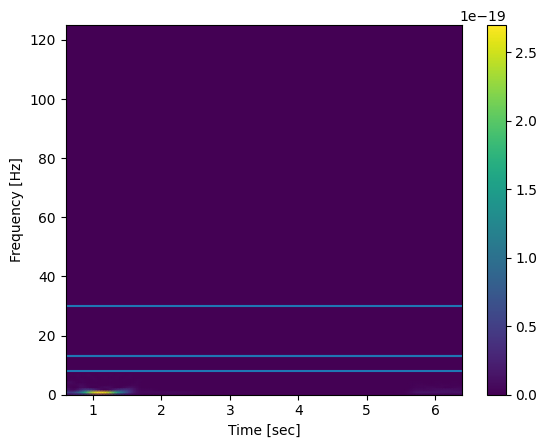

In [ ]:
import matplotlib.pyplot as plt

d_0_2 = np.array(f[refs[trial][subject]]).T # first trial - third subject. shape = (1750, 68), 1750 timepoints 250 Hz, 68 sources
type(d_0_2), d_0_2.T.shape, refs[:][2].shape
data = d2 # ( for evoked response)
data = d_0_2 # for single trial response


f, t, Sxx = spectrogram(data[9],250, nperseg=300, noverlap=290)
#f = f[:max_ind]
#Sxx = Sxx[:max_ind,:]
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar()
plt.hlines((8,13),*plt.xlim())
plt.hlines((13,30),*plt.xlim())
plt.show()

In [8]:
ntimes = Sxx.shape[0]
end_1_sec = np.argmax(t[np.where(t<1)]) - 1
Sxx_mean = Sxx[:,:end_1_sec].mean(axis=1, keepdims=True)
Sxx_std  = Sxx[:,:end_1_sec].std(axis=1, keepdims=True)
Sxx_zscore = (Sxx - Sxx_mean) / Sxx_std


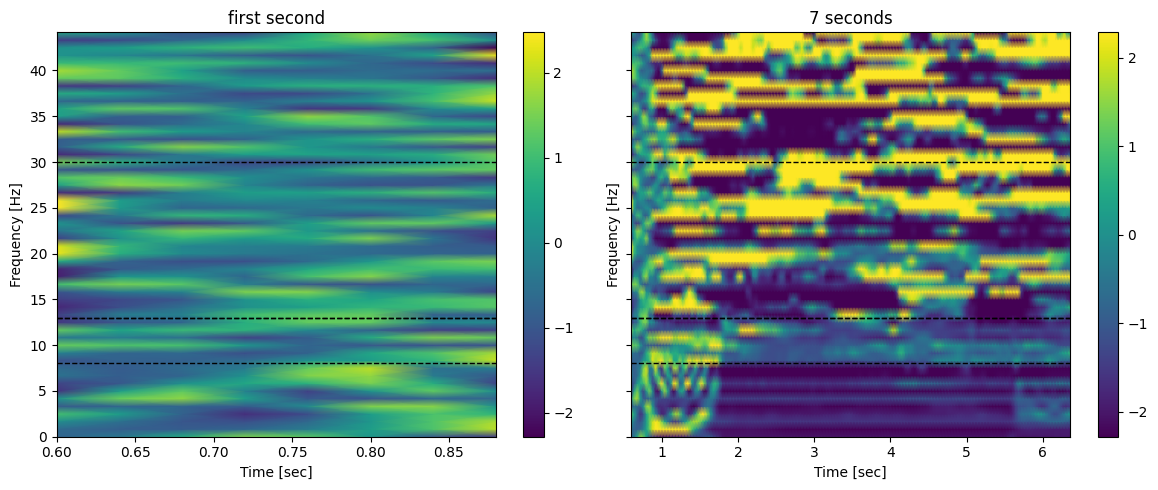

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

f45 = int(len(f) * 45 // f[-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, only1sec in zip(axes, [True, False]):
    end = end_1_sec if only1sec else -1

    im = ax.pcolormesh(
        t[:end],
        f[:f45],
        Sxx_zscore[:f45, :end],
        shading='gouraud')
    ax.set_title(f"first second" if only1sec else "7 seconds")
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [sec]')

    ax.hlines((8, 13), *ax.get_xlim(), colors='k', linestyles='dashed', linewidth=1)
    ax.hlines((13, 30), *ax.get_xlim(), colors='k', linestyles='dashed', linewidth=1)
    cbar = fig.colorbar(im, ax=ax)

    if only1sec : 
        vmin, vmax = im.get_clim()
    if not only1sec:
        vmax_new = -vmin
        im.set_clim(vmin, vmax_new)

        # Modify colormap (top color = yellow)
        orig_cmap = plt.cm.viridis
        n_colors = 256
        colors = orig_cmap(np.linspace(0, 1, n_colors))
        # colors[-1] = [1.0, 1.0, 0.0, 1.0]  # yellow
        new_cmap = LinearSegmentedColormap.from_list('viridis', colors)
        im.set_cmap(new_cmap)

        # Update colorbar
        cbar.update_normal(im)
plt.tight_layout()



## Wavelet - Morlet

In [ ]:
import numpy as np
from mne.time_frequency import tfr_array_morlet
from mne.baseline import rescale
selected_ROI = 4 # interesting ROIs 4,5, 32, 33 44 45  48 49

# Sampling frequency of my traces
sfreq = 250

freqs = np.linspace(2, 45, 100)   # frequencies to investigate - 
n_cycles = freqs*0.5          # typical compromise between time/freq resolution

# Compute time–frequency power
Wavelet_freq = tfr_array_morlet(
    d2,         # (trials, ROIs, timepoints)
    sfreq=sfreq,
    freqs=freqs,
    n_cycles=n_cycles,
    output='power'                # get power (magnitude²)
)

times = np.arange(Wavelet_freq.shape[-1])
Wavelet_freq_1ROI = Wavelet_freq[:,selected_ROI]
Wavelet_freq.shape
# (trials, rois,  freqs, times)

(96, 68, 100, 1750)

In [108]:
Wavelet_freq_1ROI.shape
# (trials,  freqs, times)

(96, 100, 1750)

In [109]:
# Apply baseline zscore
Wavelet_freq_scored = rescale(
    Wavelet_freq_1ROI,
    times=np.arange(1750)/250,
    baseline=(0.0, 0.9),    # my baseline window
    mode='percent'           # or 'ratio', 'zscore', 'mean', 'percent', etc.
)

Wavelet_freq_scored.shape
# (trials, frequencies, times)

Applying baseline correction (mode: percent)


(96, 100, 1750)

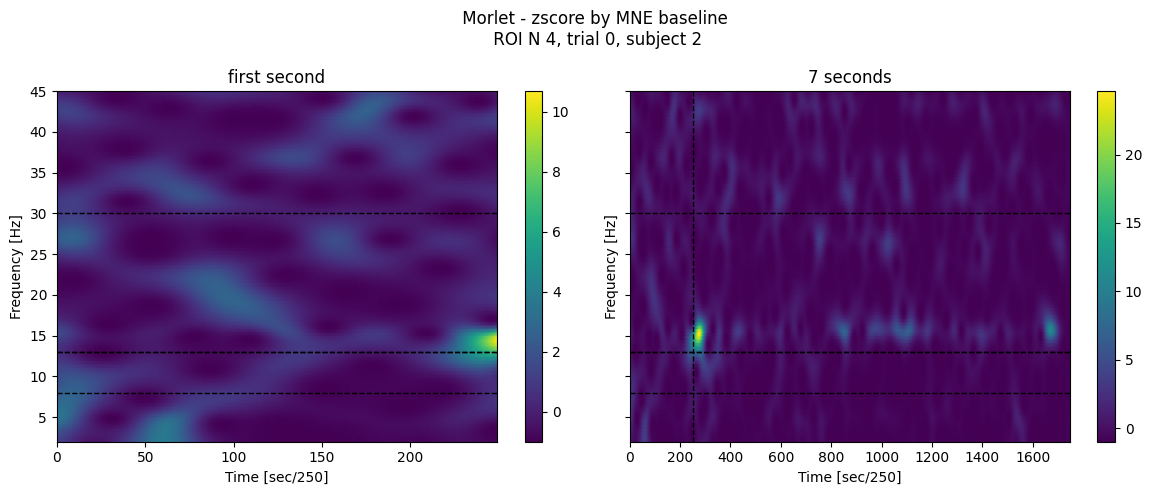

In [ ]:
tit = f" Morlet - zscore by MNE baseline \n ROI N {selected_ROI}, trial {trial}, subject {subject}"
plot_spectra(Wavelet_freq_scored[trial],freqs,times,tit,limcolorbar = False)

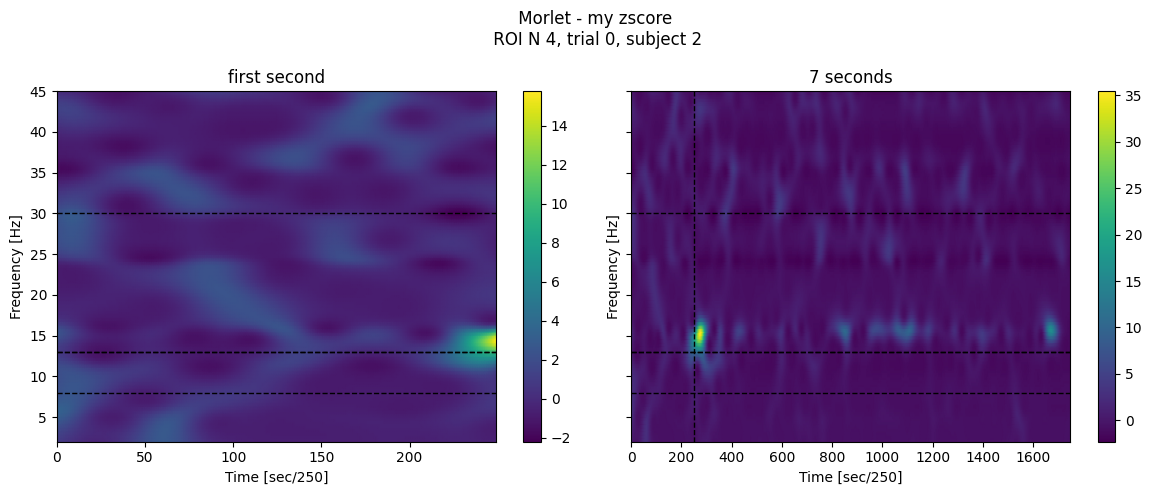

In [ ]:
Wavelet_freq_1ROI 
#(trials, freqs, timepoints)

Single_ROI_Wavelet_mean = Wavelet_freq_1ROI[:,:,:225].mean(axis=-1, keepdims=True) # 225=0.9*250
Single_ROI_Wavelet_std  = Wavelet_freq_1ROI[:,:,:225].std(axis=-1, keepdims=True)
Single_ROI_Wavelet_zscore = (Wavelet_freq_1ROI - Single_ROI_Wavelet_mean) / Single_ROI_Wavelet_std

tit = f" Morlet - my zscore \n ROI N {selected_ROI}, trial {trial}, subject {subject}"
plot_spectra(Single_ROI_Wavelet_zscore[trial],freqs,times,tit,limcolorbar = False)

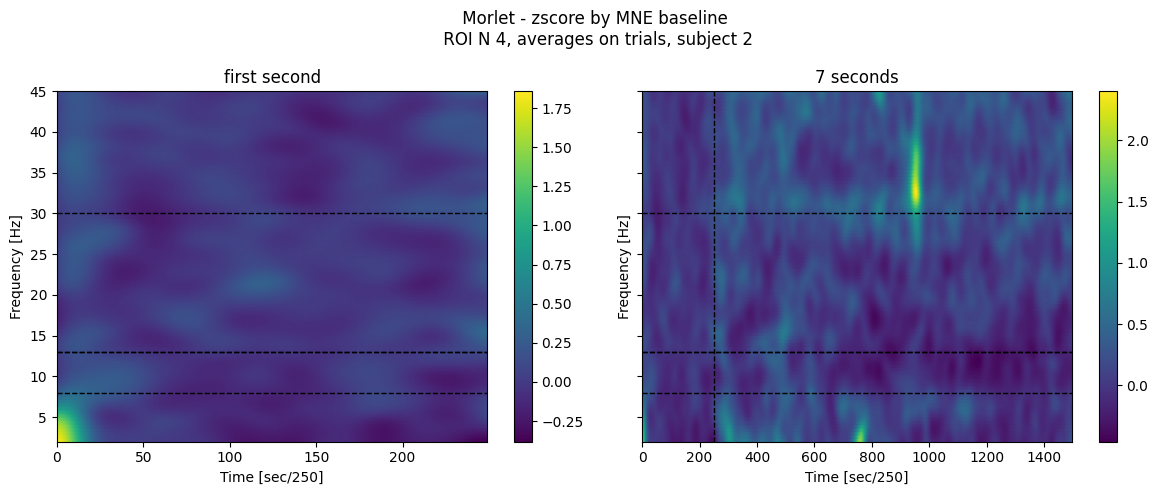

In [ ]:
tit = f" Morlet - zscore by MNE baseline \n ROI N {selected_ROI}, averages on trials, subject {subject}"
plot_spectra(Wavelet_freq_scored.mean(axis=0)[:,:-250],freqs,times[:-250],tit,limcolorbar = False)

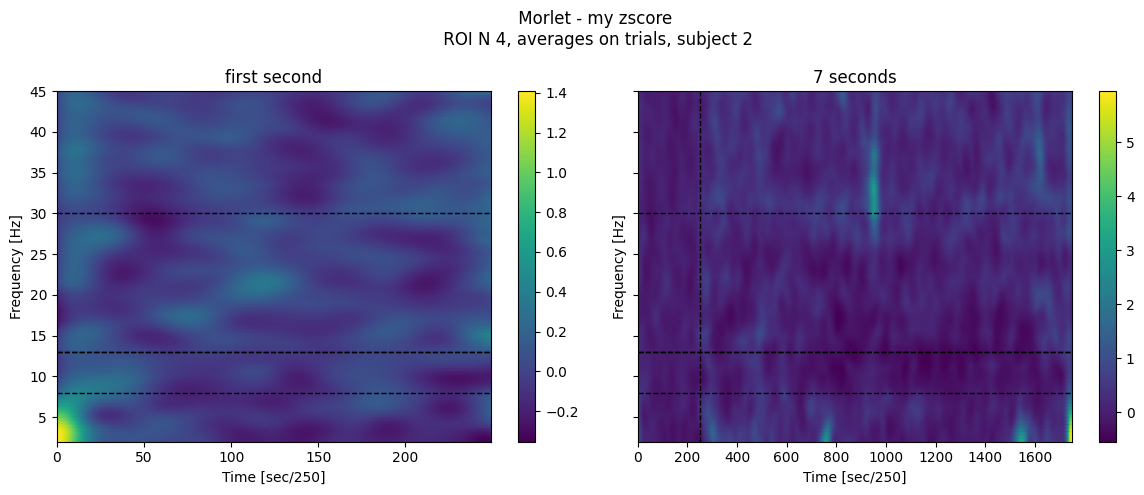

In [ ]:
tit = f" Morlet - my zscore \n ROI N {selected_ROI}, averages on trials, subject {subject}"
plot_spectra(Single_ROI_Wavelet_zscore.mean(axis=0),freqs,times,tit,limcolorbar = False)

## Multitaper

In [2]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]

Good_subjects =         [0, 2, 5, 9, 12, 14]
Ok_subjects =           [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects, "Ok_subjects":Ok_subjects, "Other_subjects":Other_subjects}

conditions = {"MI": "Data_EEG_MI_DK_V2.mat", "Rest": "Data_EEG_Baseline_DK_V2.mat" }


In [ ]:
import mne
import numpy as np
from mne.baseline import rescale
import h5py
import numpy as np
import os


condition = "Rest"              # Rest or MI
Subjects = "Good_subjects"     # Good_subjects, Ok_subjects, Other_subjects

freqs = np.linspace(2, 45, 50)  # frequencies to be investigated                        np.linspace(2, 45, 50)
n_cycles = freqs*.5             # typical compromise between time/freq resolution       freqs*.5  
time_bandwidth=3                # bandwidth of frequency mixing                         3    
baseline=(0, 0.9)               # time interval to compute mean and std to normalize    (0, 0.9)   
start_time_plot = 0             # time at wich  I start my plots                        0  



paat = f"/Users/giovanni.messuti/Desktop/BCI_project/Data/{conditions[condition]}"
# Open the file
f = h5py.File(paat, 'r')
refs = f[conditions[condition][:-7]]



In [ ]:
# My frequency sampling
sfreq = 250
Subjects_list = Subjects_dict[Subjects] # Other_subjects, Ok_subjects, Good_subjects

for subject in Subjects_list:

    data = []
    
    # 96 trials, I read each trial
    for i in range (96):
        temp_trial = np.array(f[refs[i][subject]]).T
        if temp_trial.shape == (68, 1750):
            data.append(temp_trial)
        else:
            print(f"subject_{subject} trial_{i} has wrong shape ({temp_trial.shape})")

    data=np.array(data)
    # data shape (trials, ROI, timestep)

    # path for saving images
    pat_subject = f"/Users/giovanni.messuti/Desktop/BCI_project/{Subjects}/Subject_{subject}/"
    try:
        os.mkdir(pat_subject)
    except:
        pass

    for ROI in Interesting_regions:
        Taper_spectra=mne.time_frequency.tfr_array_multitaper(data[:,ROI:ROI+1,:], 250, freqs, n_cycles, 
                                                output="power",time_bandwidth=time_bandwidth)
        times = np.arange(Taper_spectra.shape[-1])
        # Taper shape (trials, ROI, timestep)

        Taper_spectra_score = rescale(
            Taper_spectra,
            times=np.arange(1750)/250,
            baseline=baseline,    # my baseline window
            mode='percent',           # or 'ratio', 'zscore', 'mean', 'percent', etc.
            verbose=False
        )
        title =  f"Multitaper spectra - percentage norm - average on trials"
        title += f"\nnCycles=freqs*.5, bandwidth={time_bandwidth}, baseline={baseline}\n "
        title += f"subject: {subject}, ROI: {ROI}\n"
        title += f"Condition: {condition}"
        svn = pat_subject+f"Multitaper_Subject_{subject}_ROI_{ROI}_codition_{condition}.png"
        plot_spectra(Taper_spectra_score.mean(axis=(0,1))[:,:-250],
                     freqs,times=np.arange(1750-250),
                     start=start_time_plot, 
                     title=title, savename=svn)


subject_0 trial_78 has wrong shape ((2,))
subject_0 trial_79 has wrong shape ((2,))
subject_0 trial_80 has wrong shape ((2,))
subject_0 trial_81 has wrong shape ((2,))
subject_0 trial_82 has wrong shape ((2,))
subject_0 trial_83 has wrong shape ((2,))
subject_0 trial_84 has wrong shape ((2,))
subject_0 trial_85 has wrong shape ((2,))
subject_0 trial_86 has wrong shape ((2,))
subject_0 trial_87 has wrong shape ((2,))
subject_0 trial_88 has wrong shape ((2,))
subject_0 trial_89 has wrong shape ((2,))
subject_0 trial_90 has wrong shape ((2,))
subject_0 trial_91 has wrong shape ((2,))
subject_0 trial_92 has wrong shape ((2,))
subject_0 trial_93 has wrong shape ((2,))
subject_0 trial_94 has wrong shape ((2,))
subject_0 trial_95 has wrong shape ((2,))
subject_5 trial_90 has wrong shape ((2,))
subject_5 trial_91 has wrong shape ((2,))
subject_5 trial_92 has wrong shape ((2,))
subject_5 trial_93 has wrong shape ((2,))
subject_5 trial_94 has wrong shape ((2,))
subject_5 trial_95 has wrong shape

# Info on various Atlas 

(DesikanKilliany is number 2 (the third))


In [ ]:
pat_cortex="/Users/giovanni.messuti/Desktop/BCI_project/Data/cortex_15002V_MNI.mat"

import numpy as np
from scipy.io import loadmat

cortex = loadmat(pat_cortex)

In [3]:
cortex.keys()

dict_keys(['__header__', '__version__', '__globals__', 'cortex_15002V_MNI'])

In [4]:
len(cortex["cortex_15002V_MNI"][0][0])

13

In [5]:
cortex_15002V_MNI = cortex["cortex_15002V_MNI"][0]
cortex_15002V_MNI["Vertices"][0].shape      # positions
cortex_15002V_MNI["VertConn"][0].shape      # adjacency matrix
cortex_15002V_MNI["VertNormals"][0].shape   # normal vector to each vertex
cortex_15002V_MNI["Atlas"][0][0]            # All the Atlas we have
#.
#.                                          # other structural properties
#.

cortex_15002V_MNI_Atlas = cortex_15002V_MNI["Atlas"][0][0] # All the Atlas we have
cortex_15002V_MNI_Atlas.shape # info for each Atlas (Partition. We have 14 partitions)
cortex_15002V_MNI_Atlas_DesikanKilliany = cortex_15002V_MNI_Atlas[2] # chose my Atlas

In [6]:
Name_Atlas = cortex_15002V_MNI_Atlas_DesikanKilliany[0]
DesikanKilliany_Atlas = cortex_15002V_MNI_Atlas_DesikanKilliany[1]
Name_Atlas


array(['Desikan-Killiany'], dtype='<U16')

In [7]:
DesikanKilliany_Atlas.shape # 68 regions

(1, 68)

In [ ]:
X = 6
DesikanKilliany_Atlas[0,X].dtype # Region X

dtype([('Vertices', 'O'), ('Seed', 'O'), ('Color', 'O'), ('Label', 'O'), ('Function', 'O'), ('Region', 'O'), ('Handles', 'O')])

In [8]:
for i in range(len(DesikanKilliany_Atlas[0])):
    print(DesikanKilliany_Atlas[0,i]["Label"], DesikanKilliany_Atlas[0,i]["Region"])    

['bankssts L'] ['LT']
['bankssts R'] ['RT']
['caudalanteriorcingulate L'] ['LL']
['caudalanteriorcingulate R'] ['RL']
['caudalmiddlefrontal L'] ['LF']
['caudalmiddlefrontal R'] ['RF']
['cuneus L'] ['LO']
['cuneus R'] ['RO']
['entorhinal L'] ['LT']
['entorhinal R'] ['RT']
['frontalpole L'] ['LPF']
['frontalpole R'] ['RPF']
['fusiform L'] ['LT']
['fusiform R'] ['RT']
['inferiorparietal L'] ['LP']
['inferiorparietal R'] ['RP']
['inferiortemporal L'] ['LT']
['inferiortemporal R'] ['RT']
['insula L'] ['LT']
['insula R'] ['RT']
['isthmuscingulate L'] ['LL']
['isthmuscingulate R'] ['RL']
['lateraloccipital L'] ['LO']
['lateraloccipital R'] ['RO']
['lateralorbitofrontal L'] ['LPF']
['lateralorbitofrontal R'] ['RPF']
['lingual L'] ['LO']
['lingual R'] ['RO']
['medialorbitofrontal L'] ['LPF']
['medialorbitofrontal R'] ['RPF']
['middletemporal L'] ['LT']
['middletemporal R'] ['RT']
['paracentral L'] ['LC']
['paracentral R'] ['RC']
['parahippocampal L'] ['LT']
['parahippocampal R'] ['RT']
['parsop

# Load Marie spectrum Data

In [ ]:
paat2="/Users/giovanni.messuti/Desktop/BCI_project/Data/TF_AvgMI_ERDS_EEG_Sog3_68ROIs_Sess4.mat"
import h5py
import numpy as np
# Open the file

from scipy.io import loadmat

data = loadmat(paat2)


# f2 = h5py.File(paat2, 'r')
# # See all variable names
# print(list(f2.keys()))

# refs = f2['Data_EEG_MI_DK']
# print(refs),print((refs.shape)) # pointers to the arrays
# print(f2['#refs#'])



In [4]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'test'])

In [7]:
data["test"]

array([[(array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
                17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
                33, 34, 35, 36, 37, 38, 39, 40]], dtype=uint8), array([[array(['bankssts L'], dtype='<U10'),
                array(['bankssts R'], dtype='<U10'),
                array(['caudalanteriorcingulate L'], dtype='<U25'),
                array(['caudalanteriorcingulate R'], dtype='<U25'),
                array(['caudalmiddlefrontal L'], dtype='<U21'),
                array(['caudalmiddlefrontal R'], dtype='<U21'),
                array(['cuneus L'], dtype='<U8'),
                array(['cuneus R'], dtype='<U8'),
                array(['entorhinal L'], dtype='<U12'),
                array(['entorhinal R'], dtype='<U12'),
                array(['frontalpole L'], dtype='<U13'),
                array(['frontalpole R'], dtype='<U13'),
                array(['fusiform L'], dtype='<U10'),
                array(['fusiform R'], 

# Old - Plotting part

In [6]:
import mne

# This will download the dataset if not already present
sample_data_folder = mne.datasets.sample.data_path()


In [7]:
import os

# Point MNE to the subjects folder.  mne.set_config("SUBJECTS_DIR", "/path/to/your/freesurfer/subjects", set_env=True)
subjects_dir = '/Users/giovanni.messuti/mne_data/MNE-sample-data' + "/subjects"
os.environ["SUBJECTS_DIR"] = subjects_dir

print("SUBJECTS_DIR set to:", subjects_dir)


SUBJECTS_DIR set to: /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects
